# ChicPoo Disease Classifier

Notebook ini dibuat untuk training beberapa model computer vision pada dataset feses ayam:

- `cocci` = Coccidiosis
- `healthy` = feses normal/sehat
- `ncd` = Newcastle Disease
- `salmo` = Salmonella

Target notebook:

1. Membaca dataset dari path Kaggle.
2. Membuat split **train / validation / test** secara stratified.
3. Melakukan **oversampling + augmentasi pada data train** untuk membantu kelas minoritas, terutama `ncd`.
4. Melatih beberapa model:
   - Simple CNN sebagai baseline.
   - MobileNetV2.
   - ResNet50V2.
   - EfficientNetB0.
   - EfficientNetB0 fine-tuned.
5. Menyimpan **semua model** dan output evaluasi ke `/kaggle/working`.

> Catatan: Model ini adalah alat **screening awal**, bukan diagnosis final. Hasil tetap perlu dikonfirmasi oleh dokter hewan/petugas kesehatan hewan.

## 1. Import Library

In [2]:
import os
import json
import random
import shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

2026-05-25 10:32:16.167894: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779705136.388324      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779705136.453029      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779705136.975822      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779705136.975875      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779705136.975890      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Konfigurasi Project

Pastikan `DATA_DIR` sesuai dengan struktur folder Kaggle kamu.

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Path utama dataset kamu di Kaggle
DATA_DIR = "/kaggle/input/datasets/baihaqyel/chicpoodataset"

# Jika path di atas tidak terbaca, notebook akan mencoba mencari folder chicpoodataset secara otomatis.
if not os.path.exists(DATA_DIR):
    print("DATA_DIR tidak ditemukan. Mencari folder chicpoodataset di /kaggle/input ...")
    candidates = []
    for root, dirs, files in os.walk("/kaggle/input"):
        if os.path.basename(root).lower() == "chicpoodataset":
            candidates.append(root)
    if len(candidates) > 0:
        DATA_DIR = candidates[0]
        print("DATA_DIR ditemukan:", DATA_DIR)
    else:
        raise FileNotFoundError("Folder chicpoodataset tidak ditemukan. Cek ulang path dataset Kaggle kamu.")

CLASS_NAMES = ["cocci", "healthy", "ncd", "salmo"]
NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE = 224
BATCH_SIZE = 32

# Kamu bisa naikkan epoch kalau GPU dan waktu cukup.
EPOCHS_SIMPLE_CNN = 15
EPOCHS_TRANSFER = 15
EPOCHS_FINE_TUNE = 10

# Folder output Kaggle
OUTPUT_ROOT = "/kaggle/working/poultrycare_outputs"
MODEL_DIR = os.path.join(OUTPUT_ROOT, "models")
PLOT_DIR = os.path.join(OUTPUT_ROOT, "plots")
REPORT_DIR = os.path.join(OUTPUT_ROOT, "reports")
LOG_DIR = os.path.join(OUTPUT_ROOT, "logs")

for folder in [OUTPUT_ROOT, MODEL_DIR, PLOT_DIR, REPORT_DIR, LOG_DIR]:
    os.makedirs(folder, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_ROOT:", OUTPUT_ROOT)

DATA_DIR: /kaggle/input/datasets/baihaqyel/chicpoodataset
OUTPUT_ROOT: /kaggle/working/poultrycare_outputs


## 3. Membaca Seluruh File Gambar

In [4]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
records = []

for label in CLASS_NAMES:
    class_dir = Path(DATA_DIR) / label
    if not class_dir.exists():
        raise FileNotFoundError(f"Folder kelas tidak ditemukan: {class_dir}")
    
    for img_path in class_dir.rglob("*"):
        if img_path.suffix.lower() in image_extensions:
            records.append({
                "filepath": str(img_path),
                "label": label
            })

df = pd.DataFrame(records)

print("Total gambar:", len(df))
print("Distribusi kelas:")
print(df["label"].value_counts().reindex(CLASS_NAMES))
display(df.head())

# Simpan daftar file mentah
raw_index_path = os.path.join(REPORT_DIR, "raw_image_index.csv")
df.to_csv(raw_index_path, index=False)
print("Raw image index saved to:", raw_index_path)

Total gambar: 6812
Distribusi kelas:
label
cocci      2103
healthy    2057
ncd         376
salmo      2276
Name: count, dtype: int64


,filepath,label
0,/kaggle/input/datasets/baihaqyel/chicpoodatase...,cocci
1,/kaggle/input/datasets/baihaqyel/chicpoodatase...,cocci
2,/kaggle/input/datasets/baihaqyel/chicpoodatase...,cocci
3,/kaggle/input/datasets/baihaqyel/chicpoodatase...,cocci
4,/kaggle/input/datasets/baihaqyel/chicpoodatase...,cocci


Raw image index saved to: /kaggle/working/poultrycare_outputs/reports/raw_image_index.csv


## 4. Cek Gambar Rusak

Cell ini akan mencoba membuka setiap gambar. Jika ada gambar rusak, akan dikeluarkan dari dataframe.

In [5]:
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

valid_mask = df["filepath"].apply(is_valid_image)
invalid_df = df[~valid_mask].copy()
df = df[valid_mask].reset_index(drop=True)

print("Jumlah gambar valid:", len(df))
print("Jumlah gambar rusak:", len(invalid_df))

if len(invalid_df) > 0:
    invalid_path = os.path.join(REPORT_DIR, "invalid_images.csv")
    invalid_df.to_csv(invalid_path, index=False)
    print("Daftar gambar rusak disimpan ke:", invalid_path)

Jumlah gambar valid: 6812
Jumlah gambar rusak: 0


## 5. Visualisasi Distribusi Kelas

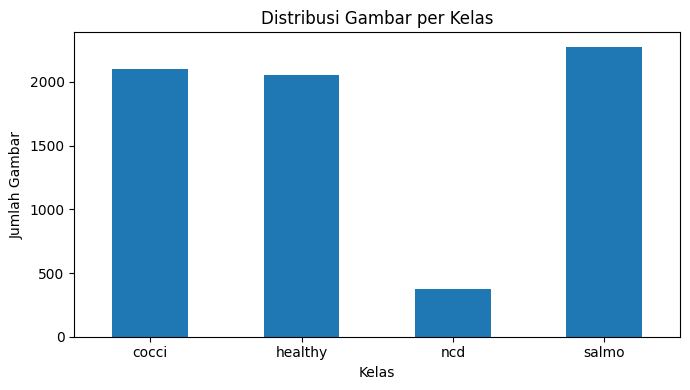

Plot saved to: /kaggle/working/poultrycare_outputs/plots/class_distribution.png


In [6]:
class_counts = df["label"].value_counts().reindex(CLASS_NAMES)

plt.figure(figsize=(7, 4))
class_counts.plot(kind="bar")
plt.title("Distribusi Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=0)
plt.tight_layout()

class_dist_plot = os.path.join(PLOT_DIR, "class_distribution.png")
plt.savefig(class_dist_plot, dpi=200)
plt.show()

print("Plot saved to:", class_dist_plot)

## 6. Split Train / Validation / Test

Skema split:

- 70% train
- 15% validation
- 15% test

Split dilakukan secara **stratified**, sehingga proporsi kelas tetap terjaga.

In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["label"].value_counts().reindex(CLASS_NAMES))

print("\nValidation distribution:")
print(val_df["label"].value_counts().reindex(CLASS_NAMES))

print("\nTest distribution:")
print(test_df["label"].value_counts().reindex(CLASS_NAMES))

train_df.to_csv(os.path.join(REPORT_DIR, "train_split_original.csv"), index=False)
val_df.to_csv(os.path.join(REPORT_DIR, "val_split.csv"), index=False)
test_df.to_csv(os.path.join(REPORT_DIR, "test_split.csv"), index=False)

Train: 4768
Validation: 1022
Test: 1022

Train distribution:
label
cocci      1472
healthy    1440
ncd         263
salmo      1593
Name: count, dtype: int64

Validation distribution:
label
cocci      315
healthy    309
ncd         56
salmo      342
Name: count, dtype: int64

Test distribution:
label
cocci      316
healthy    308
ncd         57
salmo      341
Name: count, dtype: int64


## 7. Oversampling Kelas Minoritas pada Train

Agar validasi dan test tetap realistis, oversampling hanya dilakukan pada **train set**.  
Kelas minoritas akan diduplikasi hingga jumlahnya mendekati kelas mayoritas. Karena generator memakai augmentasi, duplikasi ini akan muncul dalam variasi gambar yang berbeda saat training.

In [8]:
def oversample_train_dataframe(train_dataframe, label_col="label", random_state=SEED):
    max_count = train_dataframe[label_col].value_counts().max()
    balanced_parts = []
    
    for label, group in train_dataframe.groupby(label_col):
        if len(group) < max_count:
            sampled_group = group.sample(
                n=max_count,
                replace=True,
                random_state=random_state
            )
        else:
            sampled_group = group
        balanced_parts.append(sampled_group)
    
    balanced_df = pd.concat(balanced_parts, axis=0)
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced_df

train_balanced_df = oversample_train_dataframe(train_df)

print("Train asli:")
print(train_df["label"].value_counts().reindex(CLASS_NAMES))

print("\nTrain setelah oversampling:")
print(train_balanced_df["label"].value_counts().reindex(CLASS_NAMES))

train_balanced_df.to_csv(os.path.join(REPORT_DIR, "train_split_oversampled.csv"), index=False)

Train asli:
label
cocci      1472
healthy    1440
ncd         263
salmo      1593
Name: count, dtype: int64

Train setelah oversampling:
label
cocci      1593
healthy    1593
ncd        1593
salmo      1593
Name: count, dtype: int64


## 8. Image Generator + Augmentasi

Augmentasi hanya diterapkan pada train set. Validation dan test tidak diaugmentasi.

Penting: generator tidak melakukan `rescale`, karena preprocessing dibuat langsung di dalam model. Ini membuat model `.keras` lebih mudah dipakai saat deployment.

In [9]:
train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.12,
    height_shift_range=0.12,
    zoom_range=0.20,
    shear_range=0.10,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.75, 1.25],
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_balanced_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

with open(os.path.join(REPORT_DIR, "class_indices.json"), "w") as f:
    json.dump(train_generator.class_indices, f, indent=4)

Found 6372 validated image filenames belonging to 4 classes.
Found 1022 validated image filenames belonging to 4 classes.
Found 1022 validated image filenames belonging to 4 classes.
Class indices: {'cocci': 0, 'healthy': 1, 'ncd': 2, 'salmo': 3}


## 9. Preview Augmentasi

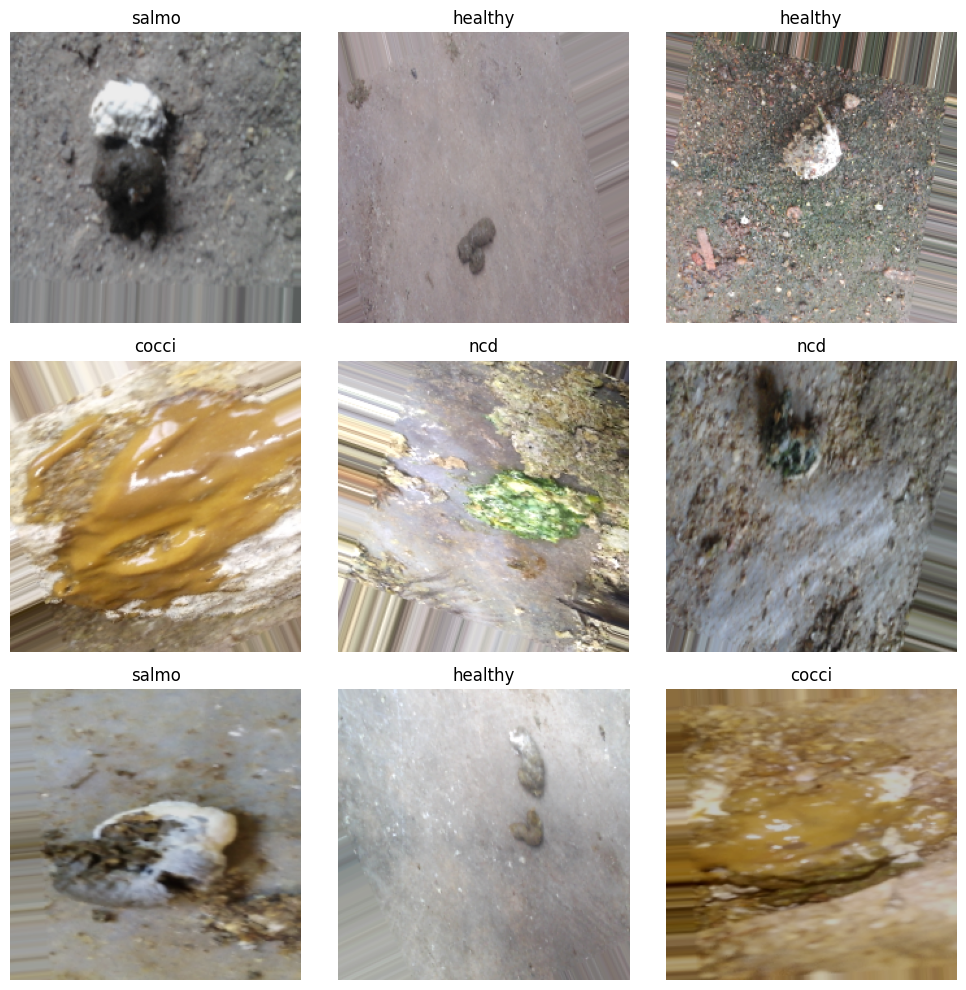

Augmentation preview saved to: /kaggle/working/poultrycare_outputs/plots/augmentation_preview.png


In [10]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    # Karena gambar masih 0-255, ubah ke uint8 untuk ditampilkan.
    plt.imshow(images[i].astype("uint8"))
    label_idx = np.argmax(labels[i])
    plt.title(CLASS_NAMES[label_idx])
    plt.axis("off")

plt.tight_layout()
aug_preview_path = os.path.join(PLOT_DIR, "augmentation_preview.png")
plt.savefig(aug_preview_path, dpi=200)
plt.show()

print("Augmentation preview saved to:", aug_preview_path)

## 10. Utility: Callback, Plot, Evaluasi, dan Simpan Model

In [11]:
trained_models = {}
model_paths = {}
evaluation_rows = []


def get_callbacks(model_name):
    best_model_path = os.path.join(MODEL_DIR, f"{model_name}_best.keras")
    log_path = os.path.join(LOG_DIR, f"{model_name}_training_log.csv")
    
    callbacks = [
        ModelCheckpoint(
            filepath=best_model_path,
            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=1
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
        CSVLogger(log_path)
    ]
    
    return callbacks


def plot_history(history, model_name):
    hist = history.history
    
    plt.figure(figsize=(7, 4))
    plt.plot(hist.get("accuracy", []), label="Train Accuracy")
    plt.plot(hist.get("val_accuracy", []), label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    acc_path = os.path.join(PLOT_DIR, f"{model_name}_accuracy.png")
    plt.savefig(acc_path, dpi=200)
    plt.show()
    
    plt.figure(figsize=(7, 4))
    plt.plot(hist.get("loss", []), label="Train Loss")
    plt.plot(hist.get("val_loss", []), label="Validation Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    loss_path = os.path.join(PLOT_DIR, f"{model_name}_loss.png")
    plt.savefig(loss_path, dpi=200)
    plt.show()
    
    return acc_path, loss_path


def evaluate_and_save_report(model, generator, model_name, split_name="test"):
    generator.reset()
    y_prob = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = generator.classes
    
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
    
    report_text = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
    
    print(f"\nClassification Report - {model_name} ({split_name})")
    print(report_text)
    
    report_df = pd.DataFrame(report_dict).transpose()
    report_csv_path = os.path.join(REPORT_DIR, f"{model_name}_{split_name}_classification_report.csv")
    report_txt_path = os.path.join(REPORT_DIR, f"{model_name}_{split_name}_classification_report.txt")
    report_df.to_csv(report_csv_path)
    with open(report_txt_path, "w") as f:
        f.write(report_text)
    
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
    cm_csv_path = os.path.join(REPORT_DIR, f"{model_name}_{split_name}_confusion_matrix.csv")
    cm_df.to_csv(cm_csv_path)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {model_name} ({split_name})")
    plt.xticks(rotation=45)
    plt.tight_layout()
    cm_png_path = os.path.join(PLOT_DIR, f"{model_name}_{split_name}_confusion_matrix.png")
    plt.savefig(cm_png_path, dpi=200)
    plt.show()
    
    row = {
        "model": model_name,
        "split": split_name,
        "accuracy": report_dict["accuracy"],
        "macro_precision": report_dict["macro avg"]["precision"],
        "macro_recall": report_dict["macro avg"]["recall"],
        "macro_f1": report_dict["macro avg"]["f1-score"],
        "weighted_precision": report_dict["weighted avg"]["precision"],
        "weighted_recall": report_dict["weighted avg"]["recall"],
        "weighted_f1": report_dict["weighted avg"]["f1-score"],
        "report_csv": report_csv_path,
        "confusion_matrix_csv": cm_csv_path,
        "confusion_matrix_png": cm_png_path
    }
    
    return row, y_true, y_pred, y_prob


def train_evaluate_save(model, model_name, train_gen, val_gen, test_gen, epochs):
    print("=" * 80)
    print(f"Training model: {model_name}")
    print("=" * 80)
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=get_callbacks(model_name),
        verbose=1
    )
    
    plot_history(history, model_name)
    
    final_model_path = os.path.join(MODEL_DIR, f"{model_name}_final.keras")
    model.save(final_model_path)
    print(f"Final model saved to: {final_model_path}")
    
    row, y_true, y_pred, y_prob = evaluate_and_save_report(
        model=model,
        generator=test_gen,
        model_name=model_name,
        split_name="test"
    )
    
    trained_models[model_name] = model
    model_paths[model_name] = final_model_path
    evaluation_rows.append(row)
    
    return history, row

## 11. Model 1 — Simple CNN Baseline

Model baseline ini tidak memakai pretrained weights. Tujuannya untuk menjadi pembanding dasar.

I0000 00:00:1779705226.496353      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779705226.502691      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "simple_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale_0_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,156 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

...

  2/200 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - accuracy: 0.2578 - loss: 2.0523 

I0000 00:00:1779705242.783706     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 19/200 ━━━━━━━━━━━━━━━━━━━━ 3:54 1s/step - accuracy: 0.4707 - loss: 1.4302

2026-05-25 10:34:27.732988: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 10:34:27.876427: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6475 - loss: 0.9172
Epoch 1: val_loss improved from inf to 2.22871, saving model to /kaggle/working/poultrycare_outputs/models/simple_cnn_best.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.6478 - loss: 0.9162 - val_accuracy: 0.3023 - val_loss: 2.2287 - learning_rate: 0.0010
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7969 - loss: 0.5534
Epoch 2: val_loss improved from 2.22871 to 1.26633, saving model to /kaggle/working/poultrycare_outputs/models/simple_cnn_best.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step - accuracy: 0.7970 - loss: 0.5532 - val_accuracy: 0.4628 - val_loss: 1.2663 - learning_rate: 0.0010
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8454 - loss: 0.4099
Epoch 3: val_loss improved from 1.26633 to 1.04028, saving model to /kaggle/working/poultrycare_outputs/models/simple_cnn_best.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 288s 1s/step - accuracy: 0.8454 - loss: 0.4098 -

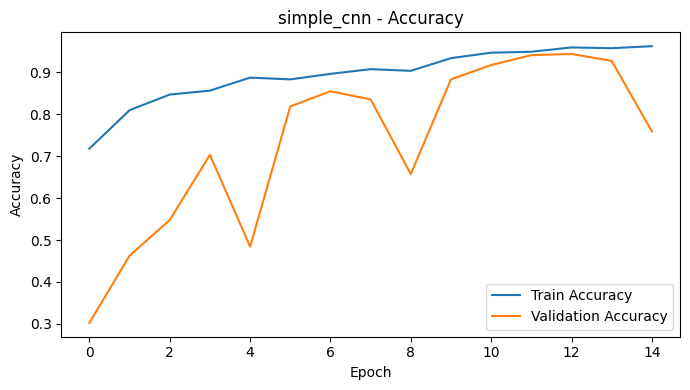

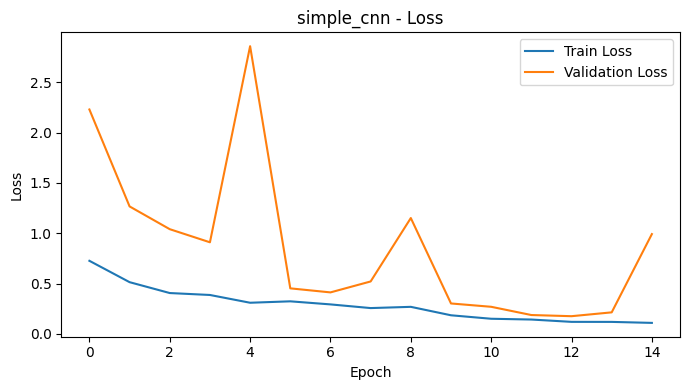

Final model saved to: /kaggle/working/poultrycare_outputs/models/simple_cnn_final.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step

Classification Report - simple_cnn (test)
              precision    recall  f1-score   support

       cocci     0.9874    0.9905    0.9889       316
     healthy     0.9503    0.9318    0.9410       308
         ncd     0.7419    0.8070    0.7731        57
       salmo     0.9472    0.9472    0.9472       341

    accuracy                         0.9481      1022
   macro avg     0.9067    0.9191    0.9126      1022
weighted avg     0.9491    0.9481    0.9485      1022



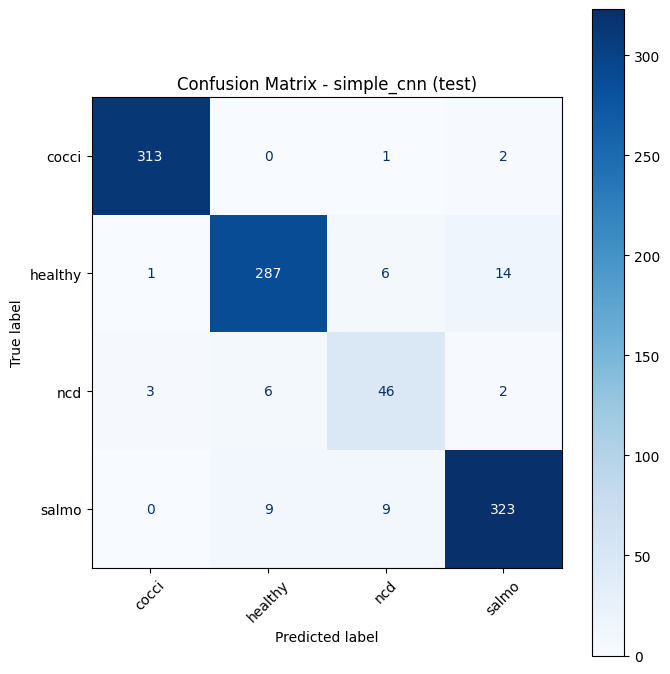

In [12]:
def build_simple_cnn():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")
    x = layers.Rescaling(1./255, name="rescale_0_1")(inputs)
    
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="prediction")(x)
    
    model = models.Model(inputs, outputs, name="simple_cnn_baseline")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

simple_cnn = build_simple_cnn()
simple_cnn.summary()

history_simple, row_simple = train_evaluate_save(
    model=simple_cnn,
    model_name="simple_cnn",
    train_gen=train_generator,
    val_gen=val_generator,
    test_gen=test_generator,
    epochs=EPOCHS_SIMPLE_CNN
)

## 12. Utility untuk Transfer Learning

Fungsi ini mencoba memakai pretrained ImageNet. Jika Kaggle internet tidak aktif dan weight belum tersedia, model otomatis memakai `weights=None` agar notebook tetap bisa berjalan.

In [13]:
def safe_application_model(app_fn, model_name, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    try:
        base_model = app_fn(
            input_shape=input_shape,
            include_top=False,
            weights="imagenet"
        )
        print(f"{model_name}: using ImageNet weights")
    except Exception as e:
        print(f"{model_name}: failed to load ImageNet weights. Using weights=None")
        print("Reason:", str(e))
        base_model = app_fn(
            input_shape=input_shape,
            include_top=False,
            weights=None
        )
    return base_model

## 13. Model 2 — MobileNetV2

MobileNetV2 ringan dan cocok untuk demo mobile-friendly.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2: using ImageNet weights


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_rescale_minus1_1    │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

...

137/200 ━━━━━━━━━━━━━━━━━━━━ 1:21 1s/step - accuracy: 0.7347 - loss: 0.7349

2026-05-25 11:50:16.973183: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 11:50:17.109561: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7660 - loss: 0.6453

2026-05-25 11:52:21.817467: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 11:52:21.964804: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from inf to 0.21506, saving model to /kaggle/working/poultrycare_outputs/models/mobilenetv2_best.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.7664 - loss: 0.6442 - val_accuracy: 0.9256 - val_loss: 0.2151 - learning_rate: 0.0010
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9017 - loss: 0.2638
Epoch 2: val_loss improved from 0.21506 to 0.19319, saving model to /kaggle/working/poultrycare_outputs/models/mobilenetv2_best.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step - accuracy: 0.9018 - loss: 0.2637 - val_accuracy: 0.9335 - val_loss: 0.1932 - learning_rate: 0.0010
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9187 - loss: 0.2263
Epoch 3: val_loss improved from 0.19319 to 0.17386, saving model to /kaggle/working/poultrycare_outputs/models/mobilenetv2_best.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.9187 - loss: 0.2262 - val_accuracy: 0.9442 - val_loss: 0.1739 - learning_rate: 0.0010
Epoch

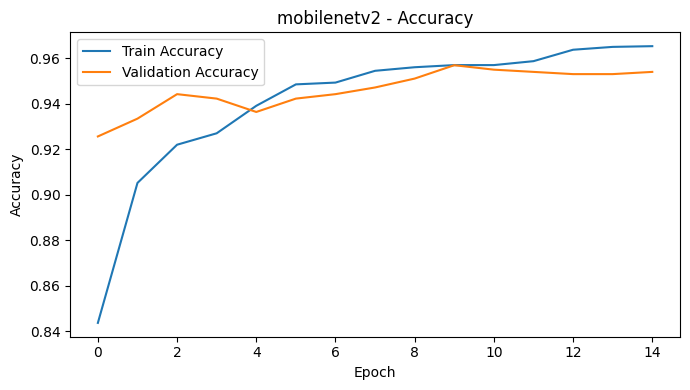

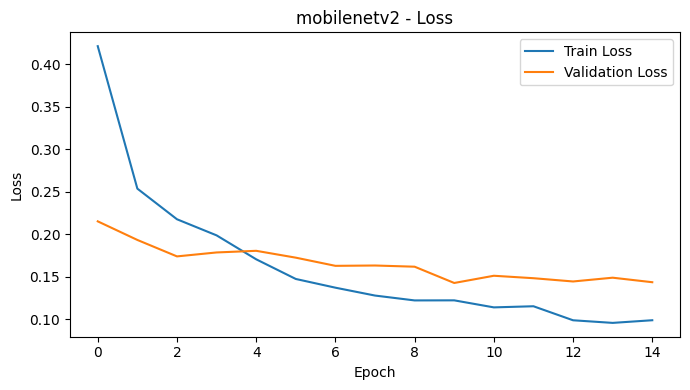

Final model saved to: /kaggle/working/poultrycare_outputs/models/mobilenetv2_final.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step 

Classification Report - mobilenetv2 (test)
              precision    recall  f1-score   support

       cocci     0.9904    0.9842    0.9873       316
     healthy     0.9831    0.9448    0.9636       308
         ncd     0.7571    0.9298    0.8346        57
       salmo     0.9708    0.9736    0.9722       341

    accuracy                         0.9658      1022
   macro avg     0.9254    0.9581    0.9394      1022
weighted avg     0.9687    0.9658    0.9666      1022



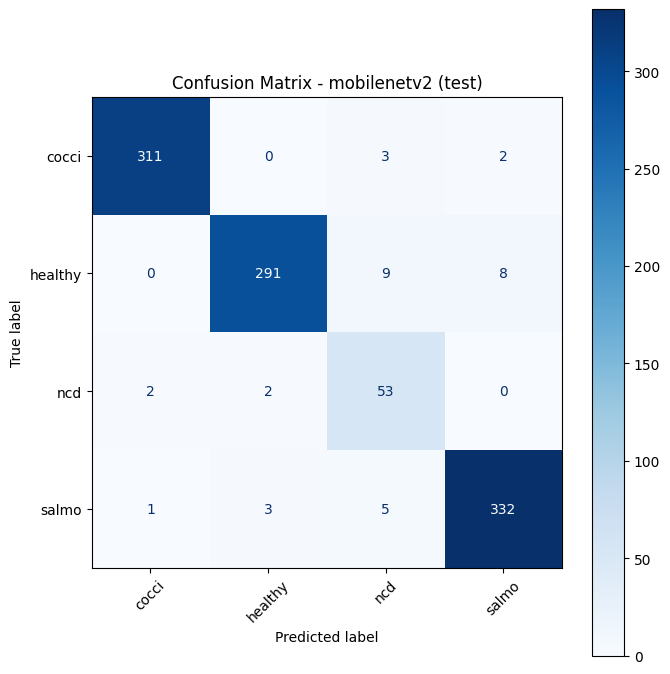

In [14]:
def build_mobilenetv2():
    base_model = safe_application_model(tf.keras.applications.MobileNetV2, "MobileNetV2")
    base_model.trainable = False
    
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")
    # MobileNetV2 pretrained lebih cocok dengan input range [-1, 1]
    x = layers.Rescaling(1./127.5, offset=-1, name="mobilenetv2_rescale_minus1_1")(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="prediction")(x)
    
    model = models.Model(inputs, outputs, name="mobilenetv2_transfer")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

mobilenetv2_model = build_mobilenetv2()
mobilenetv2_model.summary()

history_mobilenetv2, row_mobilenetv2 = train_evaluate_save(
    model=mobilenetv2_model,
    model_name="mobilenetv2",
    train_gen=train_generator,
    val_gen=val_generator,
    test_gen=test_generator,
    epochs=EPOCHS_TRANSFER
)

## 14. Model 3 — ResNet50V2

ResNet50V2 dipakai sebagai model transfer learning yang lebih dalam dibanding MobileNetV2.

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50V2: using ImageNet weights


Model: "resnet50v2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2_rescale_minus1_1     │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,615,940 (93.90 MB)

 Trainable params: 1,051,140 (4.01 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Training model: resnet50v2
Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7232 - loss: 0.8327
Epoch 1: val_loss improved from inf to 0.27577, saving model to /kaggle/working/poultrycare_outputs/models/resnet50v2_best.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.7236 - loss: 0.8313 - val_accuracy: 0.9022 - val_loss: 0.2758 - learning_rate: 0.0010
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8865 - loss: 0.3110
Epoch 2: val_loss improved from 0.27577 to 0.24992, saving model to /kaggle/working/poultrycare_outputs/models/resnet50v2_best.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.8865 - loss: 0.3110 - val_accuracy: 0.9002 - val_loss: 0.2499 - learning_rate: 0.0010
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8936 - loss: 0.2755
Epoch 3: val_loss did not improve from 0.24992
200/200 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.8936 - loss: 0.2756 - val_accuracy: 0.8826 - val_loss: 0.3243 - learn

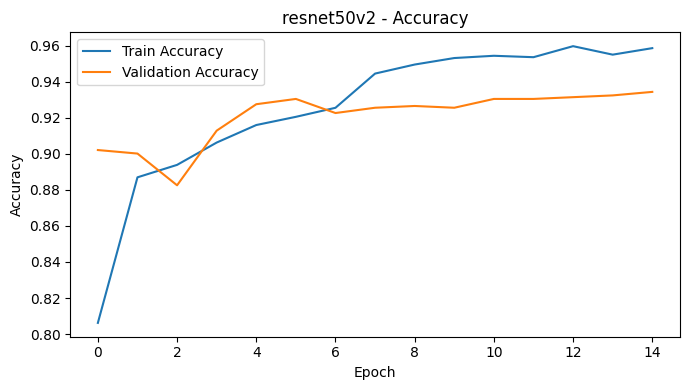

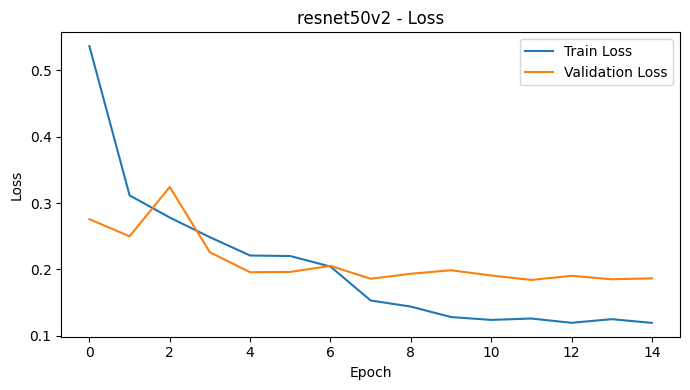

Final model saved to: /kaggle/working/poultrycare_outputs/models/resnet50v2_final.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step 

Classification Report - resnet50v2 (test)
              precision    recall  f1-score   support

       cocci     0.9810    0.9810    0.9810       316
     healthy     0.9353    0.9383    0.9368       308
         ncd     0.7541    0.8070    0.7797        57
       salmo     0.9435    0.9296    0.9365       341

    accuracy                         0.9413      1022
   macro avg     0.9035    0.9140    0.9085      1022
weighted avg     0.9420    0.9413    0.9416      1022



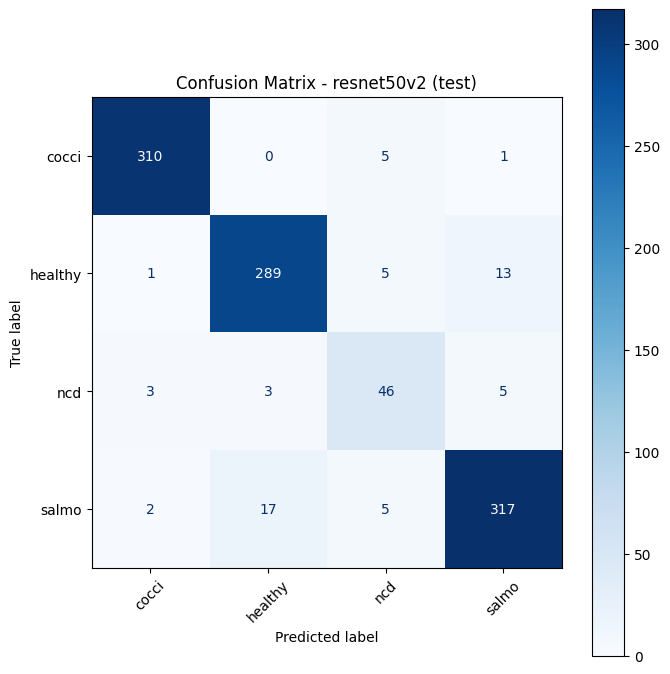

In [15]:
def build_resnet50v2():
    base_model = safe_application_model(tf.keras.applications.ResNet50V2, "ResNet50V2")
    base_model.trainable = False
    
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")
    # ResNet50V2 pretrained juga cocok dengan input range [-1, 1]
    x = layers.Rescaling(1./127.5, offset=-1, name="resnet50v2_rescale_minus1_1")(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="prediction")(x)
    
    model = models.Model(inputs, outputs, name="resnet50v2_transfer")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

resnet50v2_model = build_resnet50v2()
resnet50v2_model.summary()

history_resnet50v2, row_resnet50v2 = train_evaluate_save(
    model=resnet50v2_model,
    model_name="resnet50v2",
    train_gen=train_generator,
    val_gen=val_generator,
    test_gen=test_generator,
    epochs=EPOCHS_TRANSFER
)

## 15. Model 4 — EfficientNetB0

EfficientNetB0 biasanya kuat untuk image classification dan masih cukup ringan untuk demo.

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0: using ImageNet weights


Model: "efficientnetb0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,707,495 (17.96 MB)

 Trainable params: 657,924 (2.51 MB)

...

127/200 ━━━━━━━━━━━━━━━━━━━━ 1:32 1s/step - accuracy: 0.7965 - loss: 0.5078

2026-05-25 14:16:36.357660: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 14:16:36.492721: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 14:16:36.800911: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 14:16:36.941876: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 14:16:37.704782: E external/local_xla/xla/stream_

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8272 - loss: 0.4369

2026-05-25 14:18:53.586162: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 14:18:53.730878: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 14:18:54.081071: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 14:18:54.222911: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 14:18:55.020512: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from inf to 0.11118, saving model to /kaggle/working/poultrycare_outputs/models/efficientnetb0_frozen_best.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.8275 - loss: 0.4362 - val_accuracy: 0.9628 - val_loss: 0.1112 - learning_rate: 0.0010
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9427 - loss: 0.1555
Epoch 2: val_loss improved from 0.11118 to 0.08768, saving model to /kaggle/working/poultrycare_outputs/models/efficientnetb0_frozen_best.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 288s 1s/step - accuracy: 0.9427 - loss: 0.1555 - val_accuracy: 0.9697 - val_loss: 0.0877 - learning_rate: 0.0010
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9528 - loss: 0.1308
Epoch 3: val_loss did not improve from 0.08768
200/200 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step - accuracy: 0.9528 - loss: 0.1308 - val_accuracy: 0.9716 - val_loss: 0.0892 - learning_rate: 0.0010
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9569 - 

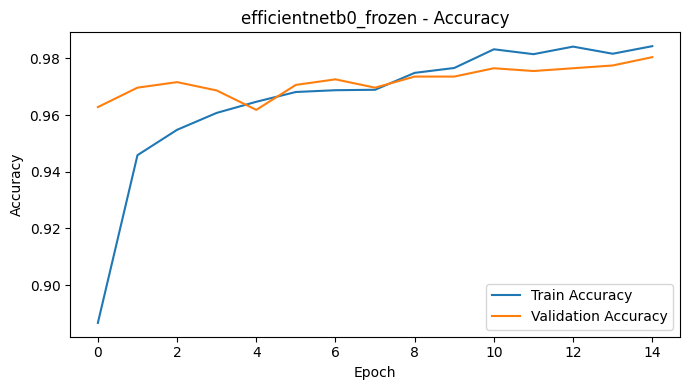

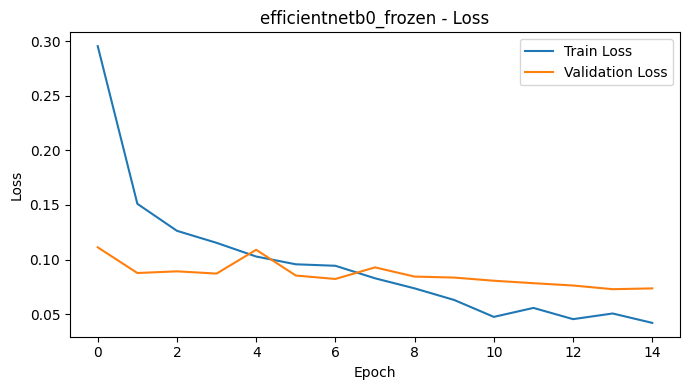

Final model saved to: /kaggle/working/poultrycare_outputs/models/efficientnetb0_frozen_final.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step

Classification Report - efficientnetb0_frozen (test)
              precision    recall  f1-score   support

       cocci     0.9937    0.9905    0.9921       316
     healthy     0.9838    0.9838    0.9838       308
         ncd     0.8983    0.9298    0.9138        57
       salmo     0.9882    0.9853    0.9868       341

    accuracy                         0.9834      1022
   macro avg     0.9660    0.9724    0.9691      1022
weighted avg     0.9835    0.9834    0.9834      1022



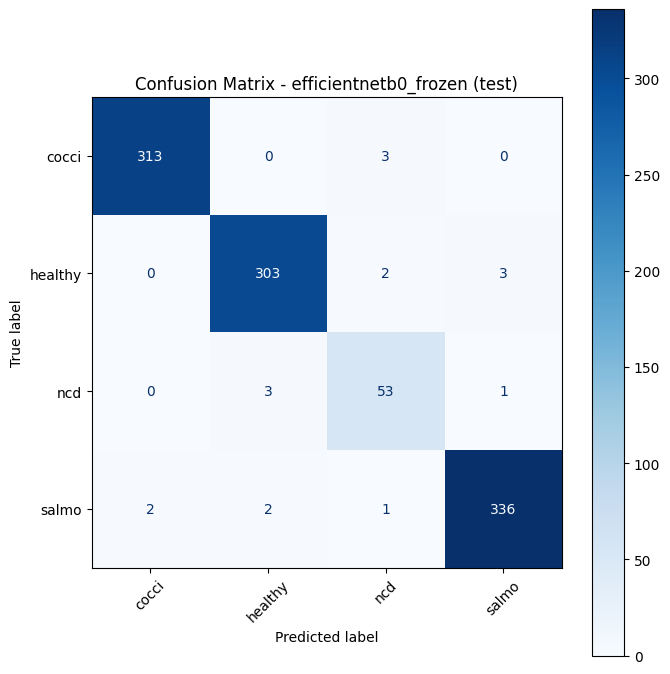

In [16]:
def build_efficientnetb0():
    base_model = safe_application_model(tf.keras.applications.EfficientNetB0, "EfficientNetB0")
    base_model.trainable = False
    
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")
    # EfficientNet Keras sudah memiliki preprocessing internal, sehingga input bisa tetap 0-255.
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="prediction")(x)
    
    model = models.Model(inputs, outputs, name="efficientnetb0_transfer")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

efficientnetb0_model = build_efficientnetb0()
efficientnetb0_model.summary()

history_efficientnetb0, row_efficientnetb0 = train_evaluate_save(
    model=efficientnetb0_model,
    model_name="efficientnetb0_frozen",
    train_gen=train_generator,
    val_gen=val_generator,
    test_gen=test_generator,
    epochs=EPOCHS_TRANSFER
)

## 16. Model 5 — Fine-tuning EfficientNetB0

Pada tahap ini, sebagian layer akhir EfficientNetB0 dibuka agar model bisa menyesuaikan fitur dengan dataset feses ayam.

Total base layers: 238
Frozen until layer index: 178
Trainable base layers: 60


Model: "efficientnetb0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,707,495 (17.96 MB)

 Trainable params: 3,329,988 (12.70 MB)

 Non-trainable params: 1,377,507 (5.25 MB)

Training model: efficientnetb0_finetuned
Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8953 - loss: 0.3032
Epoch 1: val_loss improved from inf to 0.13615, saving model to /kaggle/working/poultrycare_outputs/models/efficientnetb0_finetuned_best.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.8953 - loss: 0.3029 - val_accuracy: 0.9579 - val_loss: 0.1362 - learning_rate: 1.0000e-05
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9412 - loss: 0.1534
Epoch 2: val_loss did not improve from 0.13615
200/200 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step - accuracy: 0.9412 - loss: 0.1534 - val_accuracy: 0.9569 - val_loss: 0.1452 - learning_rate: 1.0000e-05
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9512 - loss: 0.1332
Epoch 3: val_loss did not improve from 0.13615

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
200/200 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - accuracy: 0.9512 - loss: 0.1332 - val_accuracy: 0.957

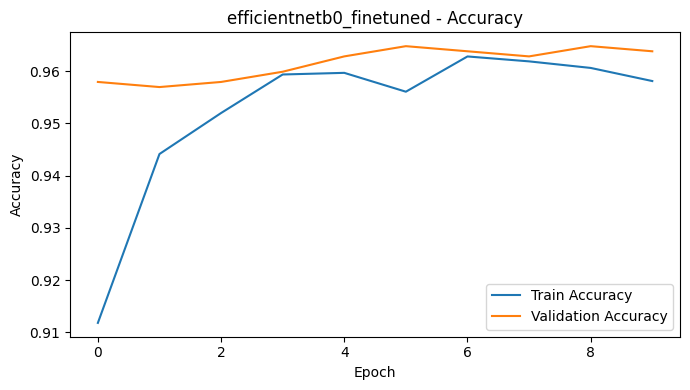

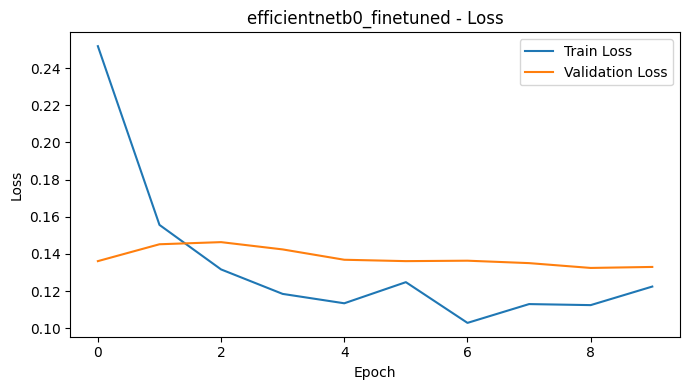

Final model saved to: /kaggle/working/poultrycare_outputs/models/efficientnetb0_finetuned_final.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step 

Classification Report - efficientnetb0_finetuned (test)
              precision    recall  f1-score   support

       cocci     0.9905    0.9905    0.9905       316
     healthy     0.9662    0.9286    0.9470       308
         ncd     0.8644    0.8947    0.8793        57
       salmo     0.9459    0.9736    0.9595       341

    accuracy                         0.9609      1022
   macro avg     0.9417    0.9469    0.9441      1022
weighted avg     0.9613    0.9609    0.9609      1022



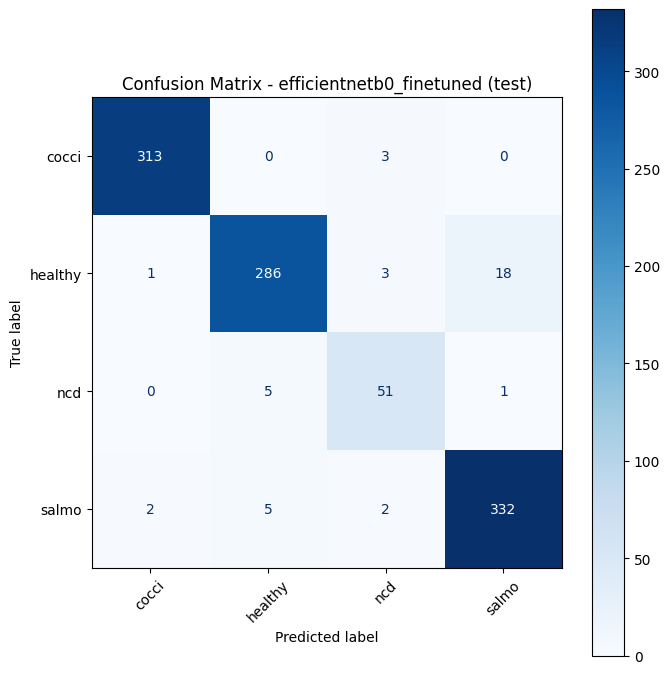

In [17]:
def fine_tune_efficientnetb0(model, unfreeze_ratio=0.25, learning_rate=1e-5):
    # Base model adalah layer kedua setelah input pada arsitektur build_efficientnetb0.
    base_model = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
            base_model = layer
            break
    
    if base_model is None:
        raise ValueError("Base EfficientNet model tidak ditemukan.")
    
    base_model.trainable = True
    n_layers = len(base_model.layers)
    fine_tune_at = int(n_layers * (1 - unfreeze_ratio))
    
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False
    
    print("Total base layers:", n_layers)
    print("Frozen until layer index:", fine_tune_at)
    print("Trainable base layers:", sum([layer.trainable for layer in base_model.layers]))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

# Fine-tune model EfficientNetB0 yang sudah dilatih frozen sebelumnya.
efficientnetb0_finetuned = fine_tune_efficientnetb0(efficientnetb0_model, unfreeze_ratio=0.25, learning_rate=1e-5)
efficientnetb0_finetuned.summary()

history_efficientnetb0_finetuned, row_efficientnetb0_finetuned = train_evaluate_save(
    model=efficientnetb0_finetuned,
    model_name="efficientnetb0_finetuned",
    train_gen=train_generator,
    val_gen=val_generator,
    test_gen=test_generator,
    epochs=EPOCHS_FINE_TUNE
)

## 17. Rekap Performa Semua Model

Model terbaik dipilih berdasarkan **macro F1-score**, karena dataset awalnya tidak seimbang dan kelas minoritas seperti `ncd` penting untuk diperhatikan.

In [18]:
evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df = evaluation_df.sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

evaluation_summary_path = os.path.join(REPORT_DIR, "evaluation_summary.csv")
evaluation_df.to_csv(evaluation_summary_path, index=False)

display(evaluation_df[[
    "model", "accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"
]])

print("Evaluation summary saved to:", evaluation_summary_path)

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,efficientnetb0_frozen,0.983366,0.965989,0.972359,0.969105,0.983440
1,efficientnetb0_finetuned,0.960861,0.941750,0.946855,0.944094,0.960866
2,mobilenetv2,0.965753,0.925364,0.958104,0.939426,0.966592
3,simple_cnn,0.948141,0.906716,0.919139,0.912562,0.948528
4,resnet50v2,0.941292,0.903460,0.913990,0.908487,0.941598


Evaluation summary saved to: /kaggle/working/poultrycare_outputs/reports/evaluation_summary.csv


## 18. Simpan Model Terbaik Otomatis

Model terbaik akan dicopy menjadi `best_model.keras`.

In [19]:
best_model_name = evaluation_df.loc[0, "model"]
best_model_source = model_paths[best_model_name]
best_model_path = os.path.join(MODEL_DIR, "best_model.keras")

shutil.copy(best_model_source, best_model_path)

best_info = {
    "best_model_name": best_model_name,
    "selection_metric": "macro_f1",
    "best_model_source": best_model_source,
    "best_model_path": best_model_path,
    "class_names": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "created_at": datetime.now().isoformat()
}

best_info_path = os.path.join(REPORT_DIR, "best_model_info.json")
with open(best_info_path, "w") as f:
    json.dump(best_info, f, indent=4)

print("Best model:", best_model_name)
print("Best model copied to:", best_model_path)
print("Best model info saved to:", best_info_path)

Best model: efficientnetb0_frozen
Best model copied to: /kaggle/working/poultrycare_outputs/models/best_model.keras
Best model info saved to: /kaggle/working/poultrycare_outputs/reports/best_model_info.json


## 19. Fungsi Prediksi Satu Gambar

Karena preprocessing sudah berada di dalam model, fungsi prediksi cukup membaca gambar sebagai array 0-255.

Sample image: /kaggle/input/datasets/baihaqyel/chicpoodataset/healthy/healthy.619.jpg


2026-05-25 16:16:36.255644: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 16:16:36.390992: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 16:16:37.143139: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 16:16:37.278243: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


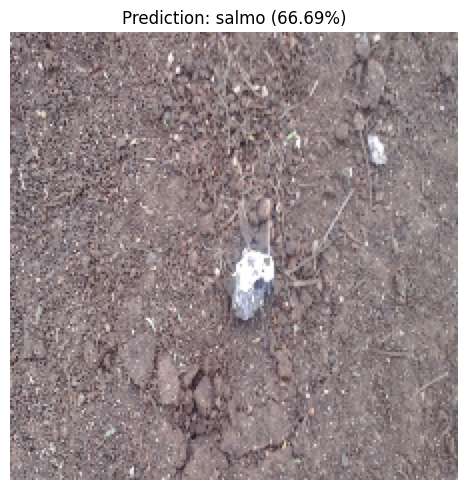

Predicted class: salmo
Confidence: 66.69%


,class,probability
0,salmo,6.669431e-01
1,healthy,3.330560e-01
2,cocci,9.289898e-07
3,ncd,8.739685e-09


In [20]:
from tensorflow.keras.preprocessing import image


def predict_single_image(model, img_path, class_names=CLASS_NAMES, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=(img_size, img_size))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    probs = model.predict(img_array, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    confidence = float(probs[pred_idx])
    
    prob_df = pd.DataFrame({
        "class": class_names,
        "probability": probs
    }).sort_values("probability", ascending=False).reset_index(drop=True)
    
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {pred_class} ({confidence:.2%})")
    plt.tight_layout()
    plt.show()
    
    return pred_class, confidence, prob_df

# Ambil sampel acak dari test set
sample_img = test_df.sample(1, random_state=SEED)["filepath"].values[0]
print("Sample image:", sample_img)

best_model = tf.keras.models.load_model(best_model_path)
pred_class, confidence, prob_df = predict_single_image(best_model, sample_img)

print("Predicted class:", pred_class)
print("Confidence:", f"{confidence:.2%}")
display(prob_df)

## 20. Rekomendasi Berdasarkan Hasil Prediksi

Rekomendasi ini bersifat edukatif dan screening awal. Untuk tindakan medis/veteriner, tetap perlu konfirmasi ahli.

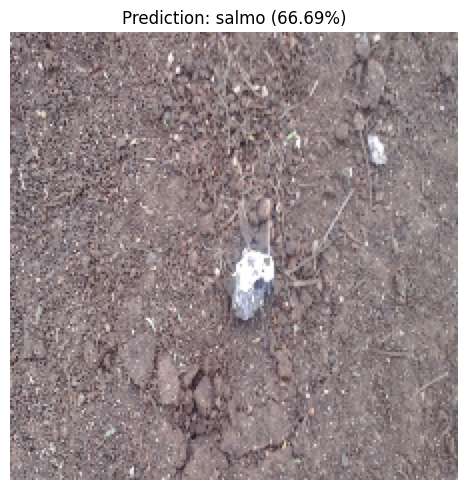


Hasil Prediksi
Kelas      : salmo
Confidence : 66.69%

Rekomendasi:
Terindikasi mirip salmonellosis. Perhatikan kebersihan kandang dan air minum, kurangi kontaminasi feses, lakukan isolasi awal, dan konsultasikan dengan petugas kesehatan hewan.

Probabilitas semua kelas:


,class,probability
0,salmo,6.669431e-01
1,healthy,3.330560e-01
2,cocci,9.289898e-07
3,ncd,8.739685e-09


('salmo',
 0.6669430732727051,
      class   probability
 0    salmo  6.669431e-01
 1  healthy  3.330560e-01
 2    cocci  9.289898e-07
 3      ncd  8.739685e-09)

In [21]:
recommendation_map = {
    "healthy": "Feses tampak menyerupai kelas sehat. Tetap jaga kebersihan kandang, kualitas pakan, air minum, dan lakukan monitoring rutin.",
    "cocci": "Terindikasi mirip coccidiosis. Pisahkan ayam yang dicurigai sakit, jaga kandang tetap kering, bersihkan litter, dan konsultasikan dengan petugas kesehatan hewan.",
    "salmo": "Terindikasi mirip salmonellosis. Perhatikan kebersihan kandang dan air minum, kurangi kontaminasi feses, lakukan isolasi awal, dan konsultasikan dengan petugas kesehatan hewan.",
    "ncd": "Terindikasi mirip Newcastle Disease. Segera pisahkan ayam yang dicurigai, batasi kontak antarayam, periksa status vaksinasi, dan hubungi petugas kesehatan hewan karena penyakit ini sangat menular."
}


def predict_with_recommendation(model, img_path):
    pred_class, confidence, prob_df = predict_single_image(model, img_path)
    
    print("\nHasil Prediksi")
    print("Kelas      :", pred_class)
    print("Confidence :", f"{confidence:.2%}")
    print("\nRekomendasi:")
    print(recommendation_map.get(pred_class, "Belum ada rekomendasi untuk kelas ini."))
    print("\nProbabilitas semua kelas:")
    display(prob_df)
    
    return pred_class, confidence, prob_df

predict_with_recommendation(best_model, sample_img)

## 21. Simpan Semua Output ke ZIP

File ZIP ini berisi:

- semua model `.keras`,
- classification report,
- confusion matrix,
- plot training,
- split data,
- info model terbaik.

In [22]:
zip_base = "/kaggle/working/poultrycare_all_outputs"
zip_path = shutil.make_archive(zip_base, "zip", OUTPUT_ROOT)

print("All outputs zipped to:", zip_path)
print("Isi folder output:")
for root, dirs, files in os.walk(OUTPUT_ROOT):
    level = root.replace(OUTPUT_ROOT, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for file in files[:10]:
        print(f"{subindent}{file}")
    if len(files) > 10:
        print(f"{subindent}... {len(files) - 10} more files")

All outputs zipped to: /kaggle/working/poultrycare_all_outputs.zip
Isi folder output:
poultrycare_outputs/
  models/
    mobilenetv2_final.keras
    resnet50v2_final.keras
    efficientnetb0_frozen_best.keras
    simple_cnn_best.keras
    efficientnetb0_frozen_final.keras
    efficientnetb0_finetuned_best.keras
    best_model.keras
    resnet50v2_best.keras
    mobilenetv2_best.keras
    efficientnetb0_finetuned_final.keras
    ... 1 more files
  reports/
    resnet50v2_test_classification_report.csv
    efficientnetb0_frozen_test_classification_report.csv
    efficientnetb0_frozen_test_confusion_matrix.csv
    resnet50v2_test_confusion_matrix.csv
    efficientnetb0_finetuned_test_confusion_matrix.csv
    val_split.csv
    resnet50v2_test_classification_report.txt
    class_indices.json
    mobilenetv2_test_classification_report.csv
    best_model_info.json
    ... 13 more files
  logs/
    simple_cnn_training_log.csv
    efficientnetb0_finetuned_training_log.csv
    mobilenetv2_traini

## 22. Catatan Interpretasi untuk Laporan

Beberapa poin penting yang bisa kamu tulis di laporan:

1. **Split train/validation/test** dilakukan sebelum augmentasi agar evaluasi tidak bocor.
2. **Oversampling hanya dilakukan pada train set** untuk membantu kelas minoritas, terutama `ncd`.
3. Evaluasi utama menggunakan **macro F1-score**, karena metrik ini lebih adil untuk dataset tidak seimbang.
4. Model terbaik otomatis disimpan sebagai `best_model.keras`.
5. Sistem sebaiknya diposisikan sebagai **alat screening awal**, bukan diagnosis final.
6. Sebelum diterapkan di Indonesia, model perlu divalidasi dengan foto feses ayam lokal untuk mengurangi risiko domain shift akibat perbedaan pakan, kandang, pencahayaan, dan jenis ayam.